In [1]:
%load_ext autoreload
%autoreload 2

import json
import os
from collections import Counter
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np

from data_sources import (
    ArcReasoningDataSetProvider,
    SciQDataSetProvider,
    GSM8KDatasetProvider,
    SVampDatasetProvider,
    SciBenchDatasetProvider,
    MMLUDataSetProvider,
    GPQADataSetProvider
)
from sklearn.metrics import roc_auc_score

#https://stackoverflow.com/questions/34387893/output-matplotlib-figure-to-svg-with-text-as-text-not-curves
plt.rcParams['svg.fonttype'] = 'none'
# plt.rcParams['font.family'] = 'Palatino Linotype'
plt.rcParams['font.family'] = 'Times New Roman'
from async_graph_bench.stores import CSVDataStore, DiskCacheStore

from datetime import datetime


def print_with_time(*args, **kwargs):
    # Get the current time
    current_time = datetime.now().strftime("%H:%M:%S")

    # Prepend the time to the message
    message = f"[{current_time}] " + " ".join(map(str, args))

    # Print the message with any additional keyword arguments
    print(message, **kwargs)

In [2]:
import sys
from pathlib import Path

# add calibration_visualization to sys.path
# project_root = Path(__file__).resolve().parent.parent  # if you run as script
project_root = Path().resolve().parent
sys.path.append(str(project_root / "calibration_visualization"))

In [3]:
data_base_path = ".\\data"
for d in ["resources", "resources/figures", "resources/tables"]:
    os.makedirs(d, exist_ok=True)

In [4]:
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, np.bool_):
            return bool(obj)
        return super().default(obj)

# Utils

In [5]:
# Extract the first match and parse it into a number
import re

pattern = r"\d+([,\.]\d+)*"


def extract_number(s):
    match = re.search(pattern, s)
    if match:
        num_str = match.group(0).replace(",", "")  # Remove commas if present
        try:
            return float(num_str) if "." in num_str else int(num_str)
        except ValueError:
            pass
    return None  # Return None if no valid number is found


# extract_number("The final numerical result is $139.52.")

def find_largest_consecutive(set_of_integers):
    i = 0
    while i in set_of_integers:
        i += 1
    return i - 1

# Datasets & Models

In [6]:
mc_datasets_dict = {
    "MMLU": {
        "data_source": lambda: MMLUDataSetProvider(limit_items=250),
        "n": 488
    },
    "ARC_Easy": {
        "data_source": lambda: ArcReasoningDataSetProvider(dataset_name="ARC-Easy", limit_items=250),
        "n": 1000
    },
    "ARC_Challenge": {
        "data_source": lambda: ArcReasoningDataSetProvider(dataset_name="ARC-Challenge", limit_items=250),
        "n": 1000
    },
    "SciQ": {
        "data_source": lambda: SciQDataSetProvider(limit_items=250),
        "n": 1000
    },
    "GPQA": {
        "data_source": lambda: GPQADataSetProvider(limit_items=250),
        "n": 448
    },
}  # total 157440 items

arithmetic_datasets_dict = {
    "GSM8K": {
        "data_source": lambda: GSM8KDatasetProvider(limit_items=250),
        "n": 1000
    },
    "SVamp": {
        "data_source": lambda: SVampDatasetProvider(limit_items=250),
        "n": 700
    },
    "SciBench": {
        "data_source": lambda: SciBenchDatasetProvider(limit_items=250),
        "n": 692
    },
}  # total 23920 items

datasets_combined = {**mc_datasets_dict, **arithmetic_datasets_dict}
for id, dataset in datasets_combined.items():
    dataset["id"] = id
    dataset["label"] = dataset["id"].replace("_", " ")
    dataset["is_arithmetic"] = id in arithmetic_datasets_dict
arithmetic_datasets = list(arithmetic_datasets_dict.values())
mc_datasets = list(mc_datasets_dict.values())
datasets = list(datasets_combined.values())

In [7]:
from models import MODELS

models = MODELS

for model in models:
    if "basename" not in model:
        model["basename"] = os.path.basename(model["name"])
    if "shortname" not in model:
        model["shortname"] = re.sub(r"(\-\d+|\-v\d.\d)$", "", model["basename"])
    model["id"] = model["basename"]

In [8]:
# select models here
#models = [m for m in models if m["type"] != "base" and any(s in m["name"] for s in ["DeepSeek", "gemma","Magistral", "Mistral", "Qwen3"])]
models = [m for m in models if m["type"] in ["instruct", "reasoning"] and m["name"].find("Magistral") == -1]

In [9]:
[m["shortname"] for m in models]

['gpt-oss-20b',
 'gpt-oss-120b',
 'Ministral-8B',
 'Mistral-Nemo-7B',
 'Mistral-Small-3.2-24B',
 'Llama-3.3-70B',
 'Llama-4-Scout-17B',
 'Qwen3-30B-A3B-Instruct',
 'Qwen3-30B-A3B-Thinking',
 'DeepSeek-Llama-70B',
 'DeepSeek-Qwen-32B',
 'google/gemma-3-27b']

# Analysis

In [10]:
import pandas as pd
from functools import reduce

In [11]:
def get_merged_dataset(directory):
    answered_correctly_df = (DiskCacheStore if "SciBench" in directory else CSVDataStore)(directory,
                                                                                          "AnsweredCorrectly").to_dataframe()
    claim_prob_df = CSVDataStore(directory, "ClaimConditionedProbability") \
        .to_dataframe() \
        .rename(columns={"estimations": "ccp"})
    p_true_df = CSVDataStore(directory, "PTrueOriginal") \
        .to_dataframe() \
        .rename(columns={"estimations": "p_true"})
    verbalized_df = CSVDataStore(directory, "Verbalized2SUEExtractor") \
        .to_dataframe() \
        .rename(columns={"estimations": "verbalized"})
    # verbalized_gpt_oss_df = CSVDataStore(directory, "Verbalized2SUEExtractor[gpt_oss]") \
    #     .to_dataframe() \
    #     .rename(columns={"estimations": "verbalized_gpt_oss"})
    dfs = [answered_correctly_df, claim_prob_df, p_true_df, verbalized_df]#, verbalized_gpt_oss_df]
    print(f"\t\t{len(answered_correctly_df)}/{len(claim_prob_df)}/{len(p_true_df)}/{len(verbalized_df)}")
    # # Check they all have the same length
    lengths = [len(df) for df in dfs]
    # if len(set(lengths)) != 1:
    #     raise ValueError(f"DataFrames have different lengths: {lengths}")

    # Merge them all together on ['id', 'iter']
    merged_df = reduce(
        lambda left, right: pd.merge(left, right, on=['id', 'iter'], how='inner'),
        dfs
    )
    # Final check: merged size must equal input size
    assert len(merged_df) == min(lengths) and len(merged_df) != 0, "Merge failed!"
    return merged_df

In [12]:
# Load Dataframes per model
dataframes = defaultdict(dict)

for dataset in datasets:
    print(f"Loading data for dataset {dataset['id']} per model...")
    for model in models:
        print(f"\tLoading model {model['basename']}...")
        df = get_merged_dataset(f"{data_base_path}/{dataset['id']}/{model['basename']}")
        dataframes[dataset["id"]][model["id"]] = df

Loading data for dataset MMLU per model...
	Loading model gpt-oss-20b...
		10000/10000/10000/10000
	Loading model gpt-oss-120b...
		10000/10000/10000/10000
	Loading model Ministral-8B-Instruct-2410...
		10000/10000/10000/10000
	Loading model Mistral-Nemo-Instruct-2407...
		10000/10000/10000/10000
	Loading model Mistral-Small-3.2-24B-Instruct-2506...
		10000/10000/10000/10000
	Loading model Llama-3.3-70B-Instruct...
		10000/10000/10000/10000
	Loading model Llama-4-Scout-17B-16E-Instruct...
		10000/10000/10000/10000
	Loading model Qwen3-30B-A3B-Instruct-2507...
		10000/10000/10000/10000
	Loading model Qwen3-30B-A3B-Thinking-2507...
		10000/10000/10000/10000
	Loading model DeepSeek-R1-Distill-Llama-70B...
		10000/10000/10000/10000
	Loading model DeepSeek-R1-Distill-Qwen-32B...
		10000/10000/10000/10000
	Loading model gemma-3-27b-it...
		10000/10000/10000/10000
Loading data for dataset ARC_Easy per model...
	Loading model gpt-oss-20b...
		10000/10000/10000/10000
	Loading model gpt-oss-120b

In [13]:
def get_df_without_invalid_answers(df):
    if "yes_no_probabilities" in df.columns:
        return df[df["yes_no_probabilities"].apply(lambda x: x is not None and sum(x) >0)]
    elif "cluster_id" in df.columns:
        return df[df["cluster_id"].notna()]
    elif "extracted_number" in df.columns:
        return df[df["extracted_number"].notna()]
    raise ValueError("Unknown Dataset format!")

In [14]:
dataframes["MMLU"]['gpt-oss-20b'].columns

Index(['id', 'iter', 'answer_token_len', 'correct_answer_idx',
       'finish_reasons', 'frequency_of_answer', 'is_correct',
       'model_guessed_its_correct', 'reasoning_token_len',
       'yes_no_probabilities', 'ccp', 'p_true', 'token_probs', 'verbalized'],
      dtype='object')

In [15]:
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors


def adjust_color(color_name, factor=0.7, lighten=True):
    """
    Adjust a named matplotlib color.

    factor < 1  -> closer to target (white if lighten, black if darken)
    factor = 1  -> original color
    """
    rgb = mcolors.to_rgb(color_name)
    target = (1, 1, 1) if lighten else (0, 0, 0)
    adjusted = tuple(factor * c + (1 - factor) * t for c, t in zip(rgb, target))
    return adjusted


color = {
    "instruct": adjust_color("tab:blue", 0.7, lighten=True),  # lighter blue
    "reasoning": adjust_color("tab:green", 0.7, lighten=True)  # darker green
}

In [16]:
def unique_count_distribution(df: pd.DataFrame, column: str = "extracted_number") -> dict:
    """
    For each id, count how many unique non-null values exist in `column`,
    then return a frequency distribution as a dict.
    """
    # Group by id and aggregate unique values
    counts = (
        df.dropna(subset=[column])  # remove NaN / None
        .groupby("id")[column]
        .nunique()  # number of unique values per id
    )

    # Ensure ids with only NaN/None are included as 0
    all_ids = df["id"].unique()
    counts = counts.reindex(all_ids, fill_value=0)

    # Build distribution
    counter = Counter(counts)
    return dict(counter)

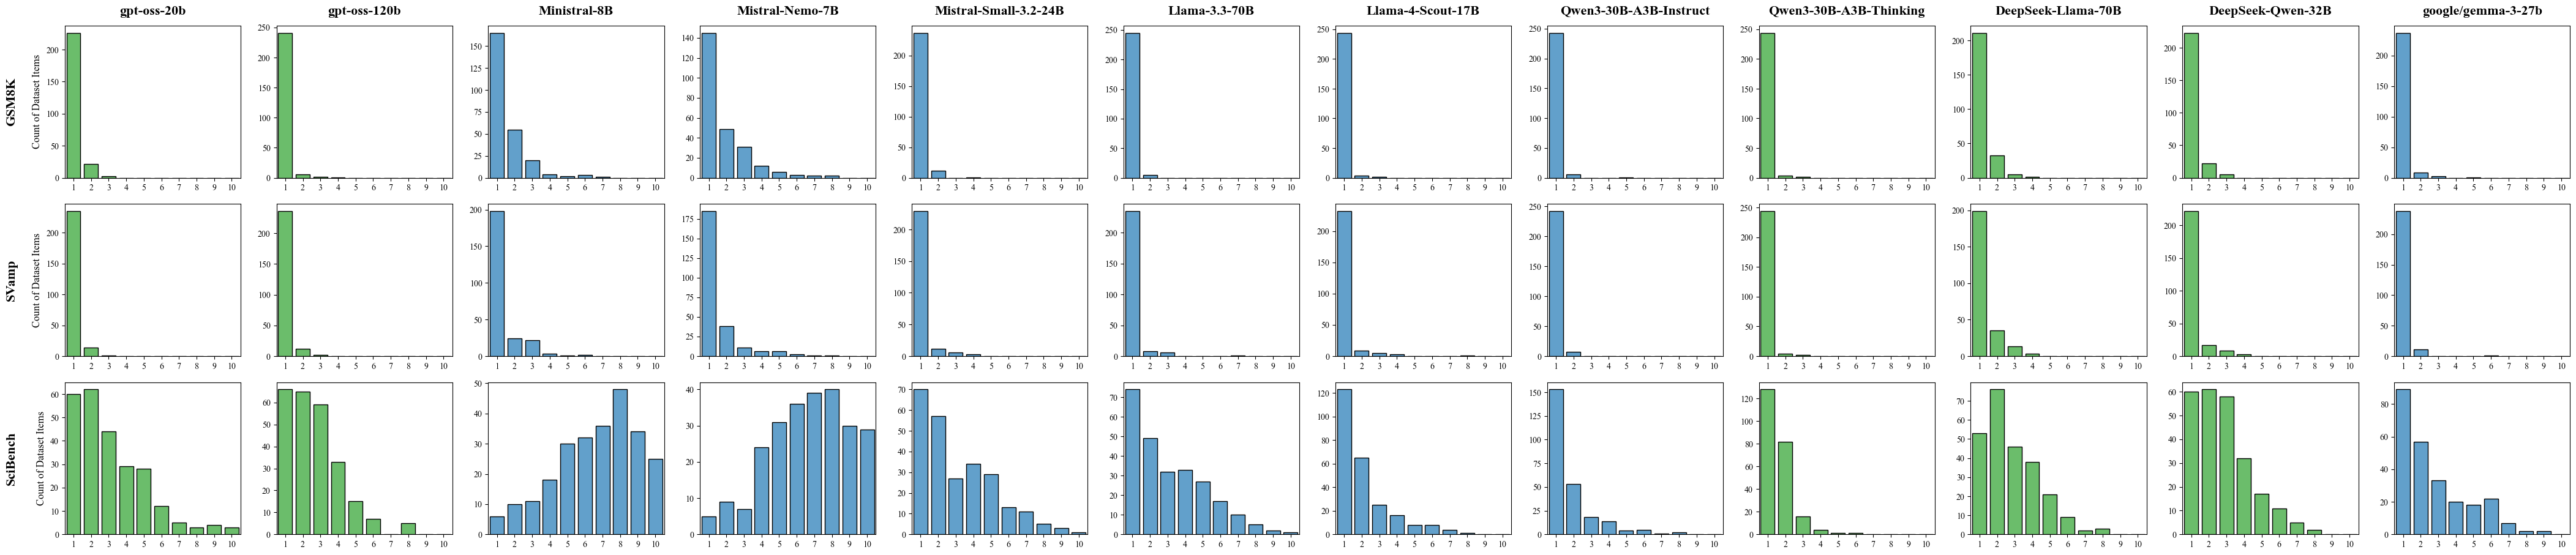

In [17]:
nrows = len(arithmetic_datasets)
ncols = len(models)

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3.5, nrows * 3.05),
                         gridspec_kw={'width_ratios': [1] * len(models),
                                      'height_ratios': [1] * len(arithmetic_datasets)},
                         squeeze=False)

# Fill row labels (dataset names)
for i, dataset in enumerate(arithmetic_datasets):
    ax = axes[i, 0]
    # ax.axis('off')
    ax.text(-0.3, 0.5, dataset['label'], ha='center', va='center', rotation='vertical', fontsize=16, fontweight='bold',
            transform=ax.transAxes)

# Fill histogram plots and annotate column labels
for i, dataset in enumerate(arithmetic_datasets):
    for j, model in enumerate(models):
        ax = axes[i, j]

        df = dataframes[dataset["id"]][model["id"]]
        count_dict = unique_count_distribution(df, "cluster_id" if dataset["id"] == "SciBench" else "extracted_number")

        values = np.array(list(count_dict.keys()))
        counts = np.array(list(count_dict.values()))
        mean = np.average(values, weights=counts)

        x_vals = list(range(1, 11))
        y_vals = [count_dict.get(x, 0) for x in x_vals]
        ax.bar(x_vals, y_vals, color=color[model["type"]], edgecolor='black')
        ax.set_xlim(0.5, 10.5)
        ax.set_xticks(x_vals)
        if i == len(datasets) - 1:
            ax.set_xlabel("Count of Different Arithmetic Results", fontsize=12)
        if j == 0:
            ax.set_ylabel("Count of Dataset Items", fontsize=12)

        # Annotate model labels above the columns
        if i == 0:  # Only annotate the top row
            ax.annotate(model['shortname'], xy=(0.5, 1.05), xycoords='axes fraction', ha='center', va='bottom',
                        fontsize=16,
                        fontweight='bold')

plt.tight_layout()
plt.savefig("resources/figures/arithmetic_answer_count.svg", bbox_inches="tight")
plt.savefig("resources/figures/arithmetic_answer_count.png", bbox_inches="tight")
plt.savefig("resources/figures/arithmetic_answer_count.pdf", bbox_inches="tight")
plt.show()

# Creating Tables for Accuracy Metrics per Dataset/Model

In [18]:
accuracy_per_ds_per_model_mc = defaultdict(lambda: dict())
accuracy_per_ds_per_model_arithmetic = defaultdict(lambda: dict())

for dataset in arithmetic_datasets:
    for model in models:
        print_with_time(f"Processing {dataset['id']}/{model['id']}")
        df = dataframes[dataset["id"]][model["id"]]
        questions_correct_counts = (df.groupby("id")["is_correct"]
                                    .sum()
                                    .reset_index(name="correct_count")
                                    )
        accuracy = df["is_correct"].sum() / len(df)
        totally_correct_questions = questions_correct_counts["correct_count"].apply(lambda x: x == 10).sum()
        accuracy_questions = totally_correct_questions / len(questions_correct_counts)
        different_given_answer_per_iter_counts = unique_count_distribution(df, "cluster_id" if dataset[
                                                                                                   "id"] == "SciBench" else "extracted_number")

        values = np.array(list(different_given_answer_per_iter_counts.keys()))
        frequencies = np.array(list(different_given_answer_per_iter_counts.values()))

        # Calculate weighted mean
        different_answer_count_mean = np.average(values, weights=frequencies)

        # Calculate weighted standard deviation
        different_answer_count_std = np.sqrt(
            np.average((values - different_answer_count_mean) ** 2, weights=frequencies))

        accuracy_per_ds_per_model_arithmetic[dataset['id']][model['id']] = {
            "totally_correct_questions": totally_correct_questions,
            "accuracy_questions": accuracy_questions,
            "accuracy": accuracy,
            "different_answer_count": different_given_answer_per_iter_counts,
            "different_answer_count_mean": different_answer_count_mean,
            "different_answer_count_std": different_answer_count_std,
        }

[11:04:32] Processing GSM8K/gpt-oss-20b
[11:04:32] Processing GSM8K/gpt-oss-120b
[11:04:32] Processing GSM8K/Ministral-8B-Instruct-2410
[11:04:32] Processing GSM8K/Mistral-Nemo-Instruct-2407
[11:04:32] Processing GSM8K/Mistral-Small-3.2-24B-Instruct-2506
[11:04:32] Processing GSM8K/Llama-3.3-70B-Instruct
[11:04:32] Processing GSM8K/Llama-4-Scout-17B-16E-Instruct
[11:04:32] Processing GSM8K/Qwen3-30B-A3B-Instruct-2507
[11:04:32] Processing GSM8K/Qwen3-30B-A3B-Thinking-2507
[11:04:32] Processing GSM8K/DeepSeek-R1-Distill-Llama-70B
[11:04:32] Processing GSM8K/DeepSeek-R1-Distill-Qwen-32B
[11:04:32] Processing GSM8K/gemma-3-27b-it
[11:04:32] Processing SVamp/gpt-oss-20b
[11:04:32] Processing SVamp/gpt-oss-120b
[11:04:32] Processing SVamp/Ministral-8B-Instruct-2410
[11:04:32] Processing SVamp/Mistral-Nemo-Instruct-2407
[11:04:32] Processing SVamp/Mistral-Small-3.2-24B-Instruct-2506
[11:04:32] Processing SVamp/Llama-3.3-70B-Instruct
[11:04:32] Processing SVamp/Llama-4-Scout-17B-16E-Instruct


In [19]:
error_count_per_model_per_question = defaultdict(lambda: dict())

for dataset in mc_datasets:
    for model in models:
        print_with_time(f"Processing {dataset['id']}/{model['id']}")
        df = dataframes[dataset["id"]][model["id"]]
        df["answer_idx"] = df["id"].apply(lambda x: x[-1])

        tp = ((df["model_guessed_its_correct"] == True) & (df["answer_idx"] == df["correct_answer_idx"])).sum()
        fp = ((df["model_guessed_its_correct"] == True) & (df["answer_idx"] != df["correct_answer_idx"])).sum()
        tn = ((df["model_guessed_its_correct"] == False) & (df["answer_idx"] != df["correct_answer_idx"])).sum()
        fn = ((df["model_guessed_its_correct"] == False) & (df["answer_idx"] == df["correct_answer_idx"])).sum()

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        accuracy = (tp + tn) / (tp + tn + fp + fn) if (tp + tn + fp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

        choices_correct_counts = (
            df.groupby("id")["is_correct"]
            .sum()
            .reset_index(name="correct_count")
        )

        # This is the number of choices answer correctly in every single iteration divided by number of question * choices
        totally_correct_choices = choices_correct_counts["correct_count"].apply(lambda x: x == 10).sum()
        accuracy_choices = totally_correct_choices / len(choices_correct_counts)

        # Step 2: Extract base_id (drop the choice index from the tuple)
        choices_correct_counts["base_id"] = choices_correct_counts["id"].apply(lambda x: x[:-1])

        it_correct_per_question = (
            choices_correct_counts.groupby("base_id")["correct_count"]
            .apply(lambda x: x.sum())  # Count how many correct_count == 10 for each base_id
            .reset_index(name="totally_correct_count")
        )
        error_count_per_model_per_question[model['id']][dataset['id']] = it_correct_per_question[
            "totally_correct_count"].apply(lambda x: 40 - x)

        # Step 4: Count how many totally correct items per base_id, keeping the zero counts
        questions_correct_counts = (
            choices_correct_counts.groupby("base_id")["correct_count"]
            .apply(lambda x: (x == 10).sum())  # Count how many correct_count == 10 for each base_id
            .reset_index(name="totally_correct_count")
        )

        totally_correct_questions = questions_correct_counts["totally_correct_count"].apply(lambda x: x == 4).sum()
        accuracy_questions = totally_correct_questions / len(questions_correct_counts)

        accuracy_per_ds_per_model_mc[dataset['id']][model['id']] = {
            "totally_correct_choices": totally_correct_choices,
            "accuracy_choices": accuracy_choices,
            "totally_correct_questions": totally_correct_questions,
            "accuracy_questions": accuracy_questions,
            "precision": precision,
            "recall": recall,
            "accuracy": accuracy,
            "f1": f1,
            "tp": tp,
            "fp": fp,
            "tn": tn,
            "fn": fn,
        }

with open("resources/accuracy_per_ds_per_model_mc.json", 'w', encoding='utf-8') as file:
    json.dump(accuracy_per_ds_per_model_mc, file, indent=4, ensure_ascii=False, cls=NumpyEncoder)

[11:04:32] Processing MMLU/gpt-oss-20b
[11:04:32] Processing MMLU/gpt-oss-120b
[11:04:32] Processing MMLU/Ministral-8B-Instruct-2410
[11:04:33] Processing MMLU/Mistral-Nemo-Instruct-2407
[11:04:33] Processing MMLU/Mistral-Small-3.2-24B-Instruct-2506
[11:04:33] Processing MMLU/Llama-3.3-70B-Instruct
[11:04:33] Processing MMLU/Llama-4-Scout-17B-16E-Instruct
[11:04:33] Processing MMLU/Qwen3-30B-A3B-Instruct-2507
[11:04:33] Processing MMLU/Qwen3-30B-A3B-Thinking-2507
[11:04:33] Processing MMLU/DeepSeek-R1-Distill-Llama-70B
[11:04:33] Processing MMLU/DeepSeek-R1-Distill-Qwen-32B
[11:04:33] Processing MMLU/gemma-3-27b-it
[11:04:33] Processing ARC_Easy/gpt-oss-20b
[11:04:33] Processing ARC_Easy/gpt-oss-120b
[11:04:33] Processing ARC_Easy/Ministral-8B-Instruct-2410
[11:04:33] Processing ARC_Easy/Mistral-Nemo-Instruct-2407
[11:04:33] Processing ARC_Easy/Mistral-Small-3.2-24B-Instruct-2506
[11:04:33] Processing ARC_Easy/Llama-3.3-70B-Instruct
[11:04:33] Processing ARC_Easy/Llama-4-Scout-17B-16E-

In [20]:
def generate_latex_accuracy_table(data, properties_labels, model_ids, caption):
    # Begin building the LaTeX table string
    lines = []

    # Table header
    lines.append(r'\begin{table}[htbp]')
    lines.append(r'\centering')
    lines.append(r'\makebox[\textwidth][c]{%')

    # Use standard column alignment but prepare for overlapping headers
    col_spec = 'll' + 'c' * len(model_ids)
    lines.append(r'\begin{tabular}{' + col_spec + '}')
    # lines.append(r'\hline')

    # Rotated model names in zero-width parboxes to allow overlap
    header = ['Dataset', 'Metric'] + [
        r'\parbox[t]{0mm}{\rotatebox{60}{' + m + '}}' for m in model_ids
    ]
    lines.append(' & '.join(header) + r' \\')
    lines.append(r'\hline')

    # For each dataset, output a multirow spanning the number of properties
    for ds, props_for_model in data.items():
        # Replace underscores with hyphens in the dataset name
        ds_label = ds.replace('_', ' ')
        n_props = len(properties_labels)
        prop_lines = []
        # For each property, get its label and then fetch each model's value from the nested dict
        for i, (prop, label) in enumerate(properties_labels.items()):
            row = []
            if i == 0:
                row.append(r'\multirow{' + f'{n_props}' + r'}{*}{' + ds_label + '}')
            else:
                row.append('')
            row.append(label)
            for m in model_ids:
                value = props_for_model.get(m, {}).get(prop, 'N/A')
                if isinstance(value, float):
                    formatted_value = f"{value:.4f}"
                else:
                    formatted_value = str(value)
                row.append(formatted_value)
            prop_lines.append(' & '.join(row) + r' \\')
        lines.extend(prop_lines)
        lines.append(r'\hline')

    lines.append(r'\end{tabular}')
    lines.append(r'}')
    lines.append(caption)
    lines.append(r'\label{tab:your_label}')
    lines.append(r'\end{table}')
    # Combine all lines into the final LaTeX code string
    latex_table = "\n".join(lines)
    return latex_table

In [21]:
model_ids = [model['id'] for model in models]
properties_labels = {
    'accuracy': 'Accuracy',
    'precision': 'Precision',
    'recall': 'Recall',
    "f1": "F1-Score",
    "accuracy_choices": "Accuracy across Choices",
    "accuracy_questions": "Accuracy across Questions",
}
caption = r'\caption[Accuracy, Precision, Recall, F1, and Consistency Metrics Across Models and MC Datasets]{\textbf{Comparison of Accuracy, Precision, Recall, F1-Score, and Consistency Metrics Across Models and Multiple‐Choice Datasets.} Shown are base accuracy, precision, recall, F1-score, accuracy across choices (proportion of correctly classified options over ten generations), and accuracy across questions (proportion of questions with all four options correct over ten generations) for each model–dataset pair.}'
latex_table = generate_latex_accuracy_table(accuracy_per_ds_per_model_mc, properties_labels, model_ids, caption)

with open(f"resources/tables/accuracy_mc_datasets.tex", "w", encoding="utf-8") as f:
    f.write(latex_table)

In [22]:
model_ids = [model['id'] for model in models]
properties_labels = {
    'accuracy': 'Accuracy',
    "accuracy_questions": "Accuracy across Questions",
    # "different_answer_count": different_given_answer_per_iter_counts,
    "different_answer_count_mean": "Mean of Different Answers across Iterations",
    # "different_answer_count_std": different_answer_count_std,
}
caption = r'\caption[Accuracy, Consistency, and Answer Variability Across Arithmetic Datasets]{\textbf{Comparison of Accuracy, Question‐Level Consistency, and Answer Variability Across Arithmetic Datasets.} Metrics include base accuracy, the proportion of questions with all correct answers over ten runs, and the mean number of distinct answers produced across iterations for each model–dataset pair.}'
latex_table = generate_latex_accuracy_table(accuracy_per_ds_per_model_arithmetic, properties_labels, model_ids, caption)

with open(f"resources/tables/accuracy_arithmetic_datasets.tex", "w", encoding="utf-8") as f:
    f.write(latex_table)

# Evaluation of Calibration

In [23]:
from plot_bucket_counts import plot_bucket_counts
from calculate_calibration_data import calculate_calibration_data, calculate_calibration_data_discrete
from plot_calibration_curve import plot_calibration_curve
from ece import calculate_ece
from normalized_entropy import calculate_normalized_entropy

from scipy.stats import entropy as scipy_entropy

In [24]:
metrics = [
    {
        "label": "Verbalized Uncertainty",
        "id": "verbalized",
        "type": "certainty"
    },
    {
        "label": "P(True)",
        "id": "p_true",
        "type": "certainty"
    },
    {
        "label": "Frequency of Answer",
        "id": "frequency_of_answer",
        "type": "certainty"
    },
    {
        "label": "CCP",
        "id": "ccp",
        "type": "certainty"
    },
]

In [25]:
def plot_empty(ax, message="No Data Available"):
    """
    Displays a placeholder plot with a light grey background and a centered message.

    Args:
        ax (matplotlib.axes.Axes): The axes to plot onto.
        message (str): The message to display in the center.
    """
    ax.set_facecolor("#f0f0f0")  # Light grey background
    ax.text(0.5, 0.5, message,
            horizontalalignment='center',
            verticalalignment='center',
            fontsize=14,
            color="#555555",  # Darker grey text
            transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_frame_on(False)


calibration_plot_colors = {
    "instruct": "Blues",
    "reasoning": "Greens",
    "base": "Oranges"
}

def plot_subplot(ax, data, model_type: str, show_x_label=True, show_y_label=True):
    """Plots calibration data on a given axis and optionally adds a table."""
    plot_calibration_curve(
        data["bin_confidences"], data["bucket_accuracies"], data["bucket_counts"],
        ax=ax, colormap=calibration_plot_colors[model_type], fontsize=20, tick_fontsize=18,
        xlabel="Confidence Bins" if show_x_label else None, ylabel="Accuracy in Bin" if show_y_label else None,
    )

def plot_table(ax, data):
    table_data = [
        ["ECE", f"{data['ece']:.4f}"],
        ["AUROC", f"{data['auroc']:.4f}"],
        ["Invalid Answers", f"{data['invalid_answers']}/{data['total_items']}"],
        ["Invalid Metric Scores", f"{data['invalid_metric_scores']}/{data['total_items']-data['invalid_answers']}"],
        ["Norm. Entropy of Bucket Counts", f"{data['normalized_entropy']:.4f}"],
        ["Accuracy", f"{data['accuracy']:.4f}"],
    ]

    table = ax.table(cellText=table_data, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)

    # Iterate over each cell and set alignment based on the column.
    for (row, col), cell in table.get_celld().items():
        if col == 0:  # First column: right aligned.
            cell.PAD = 0.02
            cell.get_text().set_ha('right')
            cell.set_width(0.65)  # Adjust as needed
        elif col == 1:  # Second column: left aligned.
            cell.PAD = 0.04
            cell.get_text().set_ha('left')
            cell.set_width(0.35)  # Adjust as needed

    ax.axis('off')


def generate_grid_plot(cell_data, row_titles, col_titles, sharex=False, sharey=False,
                       with_table=False, show_axis_labels=False, skip_annotation=False, row_col_titles_font_size=32,
                       title_font_size=38, plot_title=None):
    """
    Generates a grid of subplots.

    When with_table is True, the grid will have double the rows:
      - The even-numbered rows (0,2,…) display calibration curves.
      - The odd-numbered rows (1,3,…) display the corresponding tables.

    Args:
        cell_data (list[list[tuple]]): A 2D list (rows x columns) where each cell is a tuple (data, model).
        row_titles (list[str]): Titles for each original row (displayed on the left of the calibration rows).
        col_titles (list[str]): Titles for each column (displayed on the top).
        plot_title (str): Overall title for the figure.
        sharex (bool): Whether to share the x-axis among subplots.
        sharey (bool): Whether to share the y-axis among subplots.
        figsize (tuple): Figure size. If None, computed as (n_cols*6, n_rows*6) or adjusted if with_table.
        with_table (bool): If True, each original row is split into two rows: calibration curve and table.

    Returns:
        tuple: (fig, axes) matplotlib objects.
    """
    original_n_rows = len(cell_data)
    n_cols = len(cell_data[0]) if original_n_rows else 0
    figsize = (n_cols * 6, original_n_rows * (6 + (2.0 if with_table else 0)))

    n_rows = original_n_rows * 2 if with_table else original_n_rows
    if with_table:
        # Compute figure height as calibration row height (6) plus table row height (1.8) per original row.
        # Build height ratios: for each original row, calibration row gets ratio 1 and table row gets 0.15.
        height_ratios = []
        for _ in range(original_n_rows):
            height_ratios.extend([1, 0.15])
        fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharex=sharex, sharey=sharey,
                                 gridspec_kw={'height_ratios': height_ratios})
    else:
        fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, sharex=sharex, sharey=sharey)

    # Ensure axes is a 2D array.
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = np.array([axes])
    elif n_cols == 1:
        axes = axes.reshape(n_rows, 1)

    # Loop over grid cells.
    for i in range(original_n_rows):
        for j in range(n_cols):
            subplot_ax = axes[2 * i if with_table else i, j]
            if cell_data[i][j][0] is None:
                plot_empty(subplot_ax)
            else:
                data, model_type = cell_data[i][j]
                plot_subplot(subplot_ax, data, model_type)
                subplot_ax.set_aspect(1)  # Enforce square aspect ratio.
                if with_table:
                    table_ax = axes[2 * i + 1, j]
                    plot_table(table_ax, data)
                # Keep reserved space by making redundant axis labels transparent.
                if not with_table and not show_axis_labels:
                    if i < n_rows - 1:
                        subplot_ax.xaxis.label.set_color("none")
                    if j > 0:
                        subplot_ax.yaxis.label.set_color("none")
                # Set column header on the top row (if with_table, top row of each pair i.e. when i==0).
                if i == 0 and not skip_annotation:
                    subplot_ax.set_title(col_titles[j], fontsize=row_col_titles_font_size, fontweight="bold", y=1.05)
        # Set row annotation on the leftmost subplot.
        if not skip_annotation:
            front_subplot_ax = axes[2 * i if with_table else i, 0]
            front_subplot_ax.annotate(
                row_titles[i],
                xy=(-0.26, 0.5), xycoords='axes fraction',
                fontsize=row_col_titles_font_size, fontweight="bold", ha="center", va="center", rotation=90
            )

    # Add text with absolute offset
    if plot_title and not skip_annotation:
        fig.text(0.5, 1.0, plot_title, ha='center', va='bottom', fontsize=title_font_size, fontweight='bold')
    plt.tight_layout()
    return plt

In [26]:
cached_data = defaultdict(lambda: defaultdict(lambda: dict()))

In [27]:
def create_full_plot(model, datasets, metrics, with_table, data_path, title=None, skip_annotation=False,
                     with_title=True, kwargs=dict()):
    """
    Creates and saves the full plot with subplots for all datasets and models.

    When with_table is True, each dataset row is split into two: the calibration curve (top)
    and its corresponding table (bottom). Also updates metadata and sum of token probabilities.
    """
    # global cached_data1
    global cached_data, sum_of_token_probs
    cell_data = []
    # for model in models:
    for dataset in datasets:
        model_id = model["id"]
        dataset_id =dataset['id']
        print(f"Processing {dataset_id} ...")
        row = []
        df = dataframes[dataset_id][model_id]
        clean_df = get_df_without_invalid_answers(df).dropna(subset=["is_correct"])
        invalid_answers = len(df) - len(clean_df)

        for metric in metrics:
            metric_id = metric['id']
            need_to_invert = metric["type"] == "uncertainty"
            print(f"\tProcessing {metric['label']} (metric_id={metric_id})...")
            if metric_id in cached_data[model_id][dataset_id]:
                data = cached_data[model_id][dataset_id][metric_id]
            else:
                try:
                    cleared_invalid_metric_scores = clean_df.dropna(subset=[metric_id])
                    invalid_metric_scores = len(clean_df) - len(cleared_invalid_metric_scores)
                    correct = cleared_invalid_metric_scores["is_correct"].to_list()
                    certainties = cleared_invalid_metric_scores[metric_id].to_list()
                    if need_to_invert:
                        certainties = [1.0 - c for c in certainties]
                    bin_confidences, bucket_accuracies, bucket_counts = calculate_calibration_data_discrete(correct,  certainties, 11 if metric["label"] == "Frequency of Answer" else 15)
                    ece = calculate_ece(bin_confidences, bucket_accuracies, bucket_counts)
                    auroc = roc_auc_score(correct, certainties)

                    data = {
                        "bin_confidences": bin_confidences,
                        "bucket_accuracies": bucket_accuracies,
                        "bucket_counts": bucket_counts,
                        "ece": ece,
                        "auroc": auroc,
                        "accuracy": sum(correct) / len(correct) if len(correct) else 0,
                        "average_certainty": np.mean(certainties),
                        "normalized_entropy": calculate_normalized_entropy(bucket_counts),
                        "total_items": len(df),
                        "invalid_answers": invalid_answers,
                        "invalid_metric_scores": invalid_metric_scores
                    }
                    cached_data[model_id][dataset_id][metric['id']] = data
                except Exception as e:
                    print(f"No Data available for {model_id}/{dataset_id}/{metric_id}")
                    data = None
                    raise e
            row.append((data, model["type"]))
        cell_data.append(row)

    row_titles = [ds["id"].replace("_", "-") for ds in datasets]
    col_titles = [metric["label"] for metric in metrics]  #[model["id"] for model in models]
    plot_title = title or f"Calibration Plots for Model {model['shortname']}"

    # plot = generate_grid_plot(cell_data, row_titles, col_titles, plot_title, sharex=False, sharey=False,
    #                           with_table=with_table)
    plot = generate_grid_plot(cell_data, row_titles, col_titles,
                              with_table=with_table, skip_annotation=skip_annotation,
                              plot_title=plot_title if with_title else None, **kwargs)
    return plot

In [28]:
def create_full_plot_for_metric(models, datasets, metric, with_table, data_path, title=None, skip_annotation=False,
                                with_title=True, kwargs=dict()):
    """
    Creates and saves the full plot with subplots for all datasets and models.

    When with_table is True, each dataset row is split into two: the calibration curve (top)
    and its corresponding table (bottom). Also updates metadata and sum of token probabilities.
    """
    # global cached_data1
    global cached_data, sum_of_token_probs
    cell_data = []
    metric_id = metric['id']
    for dataset in datasets:
        dataset_id = dataset['id']
        print(f"Processing {dataset_id} ...")
        row = []

        for model in models:
            model_id = model["id"]

            df = dataframes[dataset_id][model_id]
            clean_df = get_df_without_invalid_answers(df)
            invalid_answers = len(df) - len(clean_df)
            need_to_invert = metric["type"] == "uncertainty"
            print(f"\tProcessing {model['id']}...")
            if metric_id in cached_data[model_id][dataset_id]:
                #print("Found Cached Data")
                data = cached_data[model_id][dataset_id][metric_id]
            else:
                try:
                    cleared_invalid_metric_scores = clean_df.dropna(subset=[metric_id])
                    invalid_metric_scores = len(clean_df) - len(cleared_invalid_metric_scores)
                    correct = cleared_invalid_metric_scores["is_correct"].to_list()
                    certainties = cleared_invalid_metric_scores[metric_id].to_list()
                    if need_to_invert:
                        certainties = [1.0 - c for c in certainties]
                    if metric["label"] == "Frequency of Answer":
                        bin_confidences, bucket_accuracies, bucket_counts = calculate_calibration_data_discrete(correct,
                                                                                                                certainties,
                                                                                                                11)
                    else:
                        bin_confidences, bucket_accuracies, bucket_counts = calculate_calibration_data(correct,
                                                                                                       certainties,
                                                                                                       15)
                    ece = calculate_ece(bin_confidences, bucket_accuracies, bucket_counts)
                    auroc = roc_auc_score(correct, certainties)

                    data = {
                        "bin_confidences": bin_confidences,
                        "bucket_accuracies": bucket_accuracies,
                        "bucket_counts": bucket_counts,
                        "ece": ece,
                        "accuracy": sum(correct) / len(correct) if len(correct) else 0,
                        "auroc": auroc,
                        "average_certainty": np.mean(certainties),
                        "normalized_entropy": calculate_normalized_entropy(bucket_counts),
                        "total_items": len(df),
                        "invalid_answers": invalid_answers,
                        "invalid_metric_scores": invalid_metric_scores
                    }
                    cached_data[model_id][dataset_id][metric_id] = data
                except Exception as e:
                    print(f"No Data available for {model_id}/{dataset_id}/{metric_id}")
                    data = None
                    raise e
            row.append((data, model["type"]))  # True = Instruction Tuned
        cell_data.append(row)

    row_titles = [ds["id"].replace("_", "-") for ds in datasets]
    col_titles = [model["shortname"] for model in models]  #[model["id"] for model in models]
    plot_title = f"Calibration Plots for Uncertainty Metric {metric['label']}"

    plot = generate_grid_plot(cell_data, row_titles, col_titles,
                              with_table=with_table, skip_annotation=skip_annotation,
                              plot_title=plot_title if with_title else None, **kwargs)
    return plot

In [29]:
cached_data

defaultdict(<function __main__.<lambda>()>, {})

In [30]:
os.makedirs('resources/figures/by_model', exist_ok=True)
for model in models:
    for with_table in [True, False]:
        print(f"Creating plot for {model['name']} ...")
        plot = create_full_plot(model, datasets, metrics, data_path=data_base_path, with_table=with_table)
        plot.savefig(f"resources/figures/by_model/{model['id']}_calibration_plots{'_with_table' if with_table else ''}.svg", bbox_inches="tight")
        plot.savefig(f"resources/figures/by_model/{model['id']}_calibration_plots{'_with_table' if with_table else ''}.png", bbox_inches="tight")
        plot.close()

Creating plot for openai/gpt-oss-20b ...
Processing MMLU ...
	Processing Verbalized Uncertainty (metric_id=verbalized)...
	Processing P(True) (metric_id=p_true)...
	Processing Frequency of Answer (metric_id=frequency_of_answer)...
	Processing CCP (metric_id=ccp)...
Processing ARC_Easy ...
	Processing Verbalized Uncertainty (metric_id=verbalized)...
	Processing P(True) (metric_id=p_true)...
	Processing Frequency of Answer (metric_id=frequency_of_answer)...
	Processing CCP (metric_id=ccp)...
Processing ARC_Challenge ...
	Processing Verbalized Uncertainty (metric_id=verbalized)...
	Processing P(True) (metric_id=p_true)...
	Processing Frequency of Answer (metric_id=frequency_of_answer)...
	Processing CCP (metric_id=ccp)...
Processing SciQ ...
	Processing Verbalized Uncertainty (metric_id=verbalized)...
	Processing P(True) (metric_id=p_true)...
	Processing Frequency of Answer (metric_id=frequency_of_answer)...
	Processing CCP (metric_id=ccp)...
Processing GPQA ...
	Processing Verbalized Unc

In [31]:
# model = next(m for m in models if "gpt-oss-20b" in m["id"])
for model in models:
    print(f"Creating plot for {model['name']} ...")
    ds = [d for d in datasets if d['id'] in ["MMLU", "GSM8K"]]
    plot = create_full_plot(model, ds, metrics,
                            data_path=data_base_path, with_table=False,
                            # title=f"Calibration Plots for {model['id']} for Experiment 2 for MMLU and GSM8K")
                            title=None, with_title=False, kwargs={})
    plot.savefig(f"resources/figures/by_model/short_{model['id']}_calibration_plots_short.svg", bbox_inches="tight")
    plot.savefig(f"resources/figures/by_model/short_{model['id']}_calibration_plots.png", bbox_inches="tight")
    plot.close()

Creating plot for openai/gpt-oss-20b ...
Processing MMLU ...
	Processing Verbalized Uncertainty (metric_id=verbalized)...
	Processing P(True) (metric_id=p_true)...
	Processing Frequency of Answer (metric_id=frequency_of_answer)...
	Processing CCP (metric_id=ccp)...
Processing GSM8K ...
	Processing Verbalized Uncertainty (metric_id=verbalized)...
	Processing P(True) (metric_id=p_true)...
	Processing Frequency of Answer (metric_id=frequency_of_answer)...
	Processing CCP (metric_id=ccp)...
Creating plot for openai/gpt-oss-120b ...
Processing MMLU ...
	Processing Verbalized Uncertainty (metric_id=verbalized)...
	Processing P(True) (metric_id=p_true)...
	Processing Frequency of Answer (metric_id=frequency_of_answer)...
	Processing CCP (metric_id=ccp)...
Processing GSM8K ...
	Processing Verbalized Uncertainty (metric_id=verbalized)...
	Processing P(True) (metric_id=p_true)...
	Processing Frequency of Answer (metric_id=frequency_of_answer)...
	Processing CCP (metric_id=ccp)...
Creating plot f

In [32]:
os.makedirs('resources/figures/by_metric', exist_ok=True)
for metric in metrics:
    for with_table in [True, False]:
        d = datasets
        print(f"Creating plot for {metric['label']} ...")
        plot = create_full_plot_for_metric(models, d, metric, data_path=data_base_path, with_table=with_table)
        plot.savefig(f"resources/figures/by_metric/metric_{metric['label'].replace(' ', '_')}_calibration_plots{'_with_table' if with_table else ''}.svg", bbox_inches="tight")
        plot.savefig(f"resources/figures/by_metric/metric_{metric['label'].replace(' ', '_')}_calibration_plots{'_with_table' if with_table else ''}.png", bbox_inches="tight")
        plot.close()

Creating plot for Verbalized Uncertainty ...
Processing MMLU ...
	Processing gpt-oss-20b...
	Processing gpt-oss-120b...
	Processing Ministral-8B-Instruct-2410...
	Processing Mistral-Nemo-Instruct-2407...
	Processing Mistral-Small-3.2-24B-Instruct-2506...
	Processing Llama-3.3-70B-Instruct...
	Processing Llama-4-Scout-17B-16E-Instruct...
	Processing Qwen3-30B-A3B-Instruct-2507...
	Processing Qwen3-30B-A3B-Thinking-2507...
	Processing DeepSeek-R1-Distill-Llama-70B...
	Processing DeepSeek-R1-Distill-Qwen-32B...
	Processing gemma-3-27b-it...
Processing ARC_Easy ...
	Processing gpt-oss-20b...
	Processing gpt-oss-120b...
	Processing Ministral-8B-Instruct-2410...
	Processing Mistral-Nemo-Instruct-2407...
	Processing Mistral-Small-3.2-24B-Instruct-2506...
	Processing Llama-3.3-70B-Instruct...
	Processing Llama-4-Scout-17B-16E-Instruct...
	Processing Qwen3-30B-A3B-Instruct-2507...
	Processing Qwen3-30B-A3B-Thinking-2507...
	Processing DeepSeek-R1-Distill-Llama-70B...
	Processing DeepSeek-R1-Dis

# Length of responses

In [33]:
length_metadata = defaultdict(lambda: dict())
reasoning_length_metadata = defaultdict(lambda: dict())

In [34]:
for dataset in datasets:
    dataset_id = dataset['id']
    for model in models:
        if model["id"] in length_metadata[dataset['id']]:
            continue
        print(f"Processing {dataset['id']}/{model['id']} ...")
        df = dataframes[dataset['id']][model['id']]
        lengths = df["answer_token_len"]
        length_sum = sum(lengths)
        length_mean = length_sum / len(lengths)
        length_std = (sum((x - length_mean) ** 2 for x in lengths) / len(lengths)) ** 0.5

        # reasoning_lengths = df["reasoning_token_len"]
        # reasoning_lengths = df["reasoning_token_len"]
        # reasoning_length_sum = sum(reasoning_lengths)
        # reasoning_length_mean = reasoning_length_sum / len(reasoning_lengths)
        # reasoning_length_std = (sum((x - reasoning_length_mean) ** 2 for x in reasoning_lengths) / len(reasoning_lengths)) ** 0.5

        length_metadata[dataset_id][model["id"]] = {
            "sum": length_sum,
            "mean": length_mean,
            "std": length_std,
        }
        # reasoning_length_metadata[dataset_id][model["id"]] = {
        #     "sum": reasoning_length_sum,
        #     "mean": reasoning_length_mean,
        #     "std": reasoning_length_std,
        # }

Processing MMLU/gpt-oss-20b ...
Processing MMLU/gpt-oss-120b ...
Processing MMLU/Ministral-8B-Instruct-2410 ...
Processing MMLU/Mistral-Nemo-Instruct-2407 ...
Processing MMLU/Mistral-Small-3.2-24B-Instruct-2506 ...
Processing MMLU/Llama-3.3-70B-Instruct ...
Processing MMLU/Llama-4-Scout-17B-16E-Instruct ...
Processing MMLU/Qwen3-30B-A3B-Instruct-2507 ...
Processing MMLU/Qwen3-30B-A3B-Thinking-2507 ...
Processing MMLU/DeepSeek-R1-Distill-Llama-70B ...
Processing MMLU/DeepSeek-R1-Distill-Qwen-32B ...
Processing MMLU/gemma-3-27b-it ...
Processing ARC_Easy/gpt-oss-20b ...
Processing ARC_Easy/gpt-oss-120b ...
Processing ARC_Easy/Ministral-8B-Instruct-2410 ...
Processing ARC_Easy/Mistral-Nemo-Instruct-2407 ...
Processing ARC_Easy/Mistral-Small-3.2-24B-Instruct-2506 ...
Processing ARC_Easy/Llama-3.3-70B-Instruct ...
Processing ARC_Easy/Llama-4-Scout-17B-16E-Instruct ...
Processing ARC_Easy/Qwen3-30B-A3B-Instruct-2507 ...
Processing ARC_Easy/Qwen3-30B-A3B-Thinking-2507 ...
Processing ARC_Easy/

In [35]:
def make_length_table_latex(length_metadata, models, datasets_combined,
                            caption="Response Token Lengths by Model and Dataset"):
    # Extract model IDs in order
    model_ids = [m["id"] for m in models]
    # Begin building LaTeX
    lines = []
    lines.append(r"\begin{table}[ht]")
    lines.append(r"  \centering")
    lines.append(r"  \makebox[\textwidth][c]{%")
    # Column spec: 1 left for dataset + 2 columns per model
    col_spec = "l " + " ".join(["r r"] * len(model_ids))
    lines.append(r"    \begin{tabular}{" + col_spec + "}")
    lines.append(r"      \toprule")
    # First header row: multi-column model names (rotated)
    header_cells = ["Dataset"]
    for mid in model_ids:
        rot = fr"\parbox[t]{{0mm}}{{\rotatebox{{60}}{{{mid}}}}}"
        header_cells.append(rf"\multicolumn{{2}}{{c}}{{{rot}}}")
    lines.append("      " + " & ".join(header_cells) + r" \\")
    lines.append(r"      \midrule")
    # Second header row: sub‐columns
    subcells = [""]  # blank under "Dataset"
    for _ in model_ids:
        subcells += [r"Mean", r"$\pm$Std"]
    lines.append("      " + " & ".join(subcells) + r" \\")
    lines.append(r"      \midrule")
    # Data rows
    for dataset_id in datasets_combined:
        row = [dataset_id.replace("_", " ")]
        for mid in model_ids:
            stats = length_metadata[dataset_id][mid]
            mean = stats["mean"]
            std = stats["std"]
            row.append(f"{mean:.2f}")
            row.append(f"{std:.2f}")
        lines.append("      " + " & ".join(row) + r" \\")
    lines.append(r"      \bottomrule")
    lines.append(r"    \end{tabular}%")
    lines.append(r"  }")  # end makebox
    lines.append(rf"  \caption{{{caption}}}")
    lines.append(r"\end{table}")
    # Join & return
    return "\n".join(lines)


# Example usage:
latex_table = make_length_table_latex(length_metadata, models, datasets_combined)

with open("resources/tables/response_lengths.tex", "w", encoding="utf-8") as f:
    f.write(latex_table)
print(latex_table)

\begin{table}[ht]
  \centering
  \makebox[\textwidth][c]{%
    \begin{tabular}{l r r r r r r r r r r r r r r r r r r r r r r r r}
      \toprule
      Dataset & \multicolumn{2}{c}{\parbox[t]{0mm}{\rotatebox{60}{gpt-oss-20b}}} & \multicolumn{2}{c}{\parbox[t]{0mm}{\rotatebox{60}{gpt-oss-120b}}} & \multicolumn{2}{c}{\parbox[t]{0mm}{\rotatebox{60}{Ministral-8B-Instruct-2410}}} & \multicolumn{2}{c}{\parbox[t]{0mm}{\rotatebox{60}{Mistral-Nemo-Instruct-2407}}} & \multicolumn{2}{c}{\parbox[t]{0mm}{\rotatebox{60}{Mistral-Small-3.2-24B-Instruct-2506}}} & \multicolumn{2}{c}{\parbox[t]{0mm}{\rotatebox{60}{Llama-3.3-70B-Instruct}}} & \multicolumn{2}{c}{\parbox[t]{0mm}{\rotatebox{60}{Llama-4-Scout-17B-16E-Instruct}}} & \multicolumn{2}{c}{\parbox[t]{0mm}{\rotatebox{60}{Qwen3-30B-A3B-Instruct-2507}}} & \multicolumn{2}{c}{\parbox[t]{0mm}{\rotatebox{60}{Qwen3-30B-A3B-Thinking-2507}}} & \multicolumn{2}{c}{\parbox[t]{0mm}{\rotatebox{60}{DeepSeek-R1-Distill-Llama-70B}}} & \multicolumn{2}{c}{\parbox[t]{0mm}

# ECE + Entropy

In [36]:
def make_metric_property_table_latex(
        metadata,
        models,
        datasets,
        metric,
        prop,
        label=None,
        caption=None
):
    """
    Generate a LaTeX/booktabs table for a single scalar property across models and datasets.

    Args:
        metadata: dict of form metadata[model_id][dataset_id][metric_id][...]
        models:  list of model dicts, each with an "id" key
        datasets: dict of dataset_id → dataset_info (with "is_arithmetic" flag)
        metric: one metric dict (used to pick the right metric_id per dataset)
        prop: string, which property to pull (e.g. "ece")
        label: string, column header label (e.g. "Estimated Calibration Error")
        caption: optional caption; defaults to prop if None

    Returns:
        A string containing the LaTeX code.
    """
    # Column order
    model_ids = [m["id"] for m in models]
    caption = caption or label

    lines = []
    lines.append(r"\begin{center}")
    lines.append(r"  \footnotesize")
    lines.append(r"  \centering")
    lines.append(r"  \makebox[\textwidth][c]{%")
    # One 'l' for dataset, then one 'r' per model
    col_spec = "l " + " ".join(["c"] * len(model_ids))
    lines.append(r"    \begin{tabular}{" + col_spec + "}")
    lines.append(r"      \toprule")

    # Header row: rotated model names
    header = ["Dataset"]
    for mid in model_ids:
        header.append(
            fr"\parbox[t]{{0mm}}{{\rotatebox{{60}}{{{mid}}}}}"
        )
    lines.append("      " + " & ".join(header) + r" \\")
    lines.append(r"      \midrule")

    # Data rows
    for ds_id, ds_info in datasets.items():
        row = [ds_id.replace("_", " ")]
        # choose correct metric_id for this dataset
        key = "id" if "id" in metric else (
            "arithmetic_id" if ds_info.get("is_arithmetic", False) else "mc_id"
        )
        met_id = metric[key]
        for mid in model_ids:
            val = metadata[mid][ds_id][met_id].get(prop, float("nan"))
            row.append(f"{val:.4f}")
        lines.append("      " + " & ".join(row) + r" \\")
    lines.append(r"      \bottomrule")
    lines.append(r"    \end{tabular}%")
    lines.append(r"  }")
    # lines.append(fr"  \caption{{{caption}}}")
    lines.append(fr"  \captionof{{table}}[{caption}]{{{caption}}}")
    lines.append(r"\end{center}")

    return "\n".join(lines)

In [37]:
for metric in metrics:
    latex_table = make_metric_property_table_latex(
        cached_data,
        models,
        datasets_combined if "id" in metric and metric["id"] != "CCP" else {"MMLU": mc_datasets["MMLU"],
                                                                            "GSM8K": arithmetic_datasets["GSM8K"]},
        metric=metric,
        prop="ece",
        # label="Estimated Calibration Error",
        caption="ECE by Model and Dataset for " + metric["label"]
    )
    with open(f"resources/tables/ece_{metric['label'].replace(' ', '_')}.tex", "w", encoding="utf-8") as f:
        f.write(latex_table)
    print(latex_table)

\begin{center}
  \footnotesize
  \centering
  \makebox[\textwidth][c]{%
    \begin{tabular}{l c c c c c c c c c c c c}
      \toprule
      Dataset & \parbox[t]{0mm}{\rotatebox{60}{gpt-oss-20b}} & \parbox[t]{0mm}{\rotatebox{60}{gpt-oss-120b}} & \parbox[t]{0mm}{\rotatebox{60}{Ministral-8B-Instruct-2410}} & \parbox[t]{0mm}{\rotatebox{60}{Mistral-Nemo-Instruct-2407}} & \parbox[t]{0mm}{\rotatebox{60}{Mistral-Small-3.2-24B-Instruct-2506}} & \parbox[t]{0mm}{\rotatebox{60}{Llama-3.3-70B-Instruct}} & \parbox[t]{0mm}{\rotatebox{60}{Llama-4-Scout-17B-16E-Instruct}} & \parbox[t]{0mm}{\rotatebox{60}{Qwen3-30B-A3B-Instruct-2507}} & \parbox[t]{0mm}{\rotatebox{60}{Qwen3-30B-A3B-Thinking-2507}} & \parbox[t]{0mm}{\rotatebox{60}{DeepSeek-R1-Distill-Llama-70B}} & \parbox[t]{0mm}{\rotatebox{60}{DeepSeek-R1-Distill-Qwen-32B}} & \parbox[t]{0mm}{\rotatebox{60}{gemma-3-27b-it}} \\
      \midrule
      MMLU & 0.0362 & 0.0330 & 0.4632 & 0.4834 & 0.1352 & 0.1299 & 0.1679 & 0.6407 & 0.7209 & 0.0681 & 0.0995 & 0.4

In [38]:
for metric in metrics:
    latex_table = make_metric_property_table_latex(
        cached_data,
        models,
        datasets_combined if "id" in metric and metric["id"] != "CCP" else {"MMLU": mc_datasets["MMLU"],
                                                                            "GSM8K": arithmetic_datasets["GSM8K"]},
        metric=metric,
        prop="normalized_entropy",
        # label="Estimated Calibration Error",
        caption="Normalized Entropy of Bucket Counts by Model and Dataset for " + metric["label"]
    )
    with open(f"resources/tables/normalized_entropy_{metric['label'].replace(' ', '_')}.tex", "w", encoding="utf-8") as f:
        f.write(latex_table)
    print(latex_table)

\begin{center}
  \footnotesize
  \centering
  \makebox[\textwidth][c]{%
    \begin{tabular}{l c c c c c c c c c c c c}
      \toprule
      Dataset & \parbox[t]{0mm}{\rotatebox{60}{gpt-oss-20b}} & \parbox[t]{0mm}{\rotatebox{60}{gpt-oss-120b}} & \parbox[t]{0mm}{\rotatebox{60}{Ministral-8B-Instruct-2410}} & \parbox[t]{0mm}{\rotatebox{60}{Mistral-Nemo-Instruct-2407}} & \parbox[t]{0mm}{\rotatebox{60}{Mistral-Small-3.2-24B-Instruct-2506}} & \parbox[t]{0mm}{\rotatebox{60}{Llama-3.3-70B-Instruct}} & \parbox[t]{0mm}{\rotatebox{60}{Llama-4-Scout-17B-16E-Instruct}} & \parbox[t]{0mm}{\rotatebox{60}{Qwen3-30B-A3B-Instruct-2507}} & \parbox[t]{0mm}{\rotatebox{60}{Qwen3-30B-A3B-Thinking-2507}} & \parbox[t]{0mm}{\rotatebox{60}{DeepSeek-R1-Distill-Llama-70B}} & \parbox[t]{0mm}{\rotatebox{60}{DeepSeek-R1-Distill-Qwen-32B}} & \parbox[t]{0mm}{\rotatebox{60}{gemma-3-27b-it}} \\
      \midrule
      MMLU & 0.2597 & 0.4023 & 0.5628 & 0.5390 & 0.4438 & 0.5025 & 0.2401 & 0.1180 & 0.0723 & 0.3401 & 0.4863 & 0.6

In [39]:
for metric in metrics:
    latex_table = make_metric_property_table_latex(
        cached_data,
        models,
        datasets_combined if "id" in metric and metric["id"] != "CCP" else {"MMLU": mc_datasets["MMLU"],
                                                                            "GSM8K": arithmetic_datasets["GSM8K"]},
        metric=metric,
        prop="auroc",
        # label="Estimated Calibration Error",
        caption="AUROC by Model and Dataset for " + metric["label"]
    )
    with open(f"resources/tables/auroc_{metric['label'].replace(' ', '_')}.tex", "w", encoding="utf-8") as f:
        f.write(latex_table)
    print(latex_table)

\begin{center}
  \footnotesize
  \centering
  \makebox[\textwidth][c]{%
    \begin{tabular}{l c c c c c c c c c c c c}
      \toprule
      Dataset & \parbox[t]{0mm}{\rotatebox{60}{gpt-oss-20b}} & \parbox[t]{0mm}{\rotatebox{60}{gpt-oss-120b}} & \parbox[t]{0mm}{\rotatebox{60}{Ministral-8B-Instruct-2410}} & \parbox[t]{0mm}{\rotatebox{60}{Mistral-Nemo-Instruct-2407}} & \parbox[t]{0mm}{\rotatebox{60}{Mistral-Small-3.2-24B-Instruct-2506}} & \parbox[t]{0mm}{\rotatebox{60}{Llama-3.3-70B-Instruct}} & \parbox[t]{0mm}{\rotatebox{60}{Llama-4-Scout-17B-16E-Instruct}} & \parbox[t]{0mm}{\rotatebox{60}{Qwen3-30B-A3B-Instruct-2507}} & \parbox[t]{0mm}{\rotatebox{60}{Qwen3-30B-A3B-Thinking-2507}} & \parbox[t]{0mm}{\rotatebox{60}{DeepSeek-R1-Distill-Llama-70B}} & \parbox[t]{0mm}{\rotatebox{60}{DeepSeek-R1-Distill-Qwen-32B}} & \parbox[t]{0mm}{\rotatebox{60}{gemma-3-27b-it}} \\
      \midrule
      MMLU & 0.6754 & 0.7720 & 0.3979 & 0.3726 & 0.6110 & 0.6694 & 0.5072 & 0.4515 & 0.5190 & 0.5782 & 0.5643 & 0.4

# Verbalized Uncertainty

In [40]:
verbalized_metadata = defaultdict(lambda: None)
if os.path.exists("resources/verbalized_metadata.json"):
    with open("resources/verbalized_metadata.json", 'r', encoding='utf-8') as file:
        verbalized_metadata = json.load(file)
        print(f"Loaded cached data!")
        for key, value in verbalized_metadata.items():
            verbalized_metadata[key] = pd.Series(value)
else:
    print(f"No cached data exists!")


No cached data exists!


In [41]:
for model in models:
    value_counts = None
    for dataset in datasets:
        df = dataframes[dataset['id']][model['id']]
        print(f"Processing {dataset_id}/{model['id']} - len= {len(df)}")
        value_count = df["verbalized"].value_counts()

        if value_counts is None:
            value_counts = value_count
        else:
            value_counts = value_counts.add(value_count, fill_value=0)
    verbalized_metadata[model['id']] = value_counts

with open("resources/verbalized_metadata.json", 'w', encoding='utf-8') as file:
    json.dump({key: item.to_dict() for key, item in verbalized_metadata.items()}, file, indent=4, ensure_ascii=False,
              cls=NumpyEncoder)

Processing SciBench/gpt-oss-20b - len= 10000
Processing SciBench/gpt-oss-20b - len= 10000
Processing SciBench/gpt-oss-20b - len= 10000
Processing SciBench/gpt-oss-20b - len= 10000
Processing SciBench/gpt-oss-20b - len= 10000
Processing SciBench/gpt-oss-20b - len= 2500
Processing SciBench/gpt-oss-20b - len= 2500
Processing SciBench/gpt-oss-20b - len= 2500
Processing SciBench/gpt-oss-120b - len= 10000
Processing SciBench/gpt-oss-120b - len= 10000
Processing SciBench/gpt-oss-120b - len= 10000
Processing SciBench/gpt-oss-120b - len= 10000
Processing SciBench/gpt-oss-120b - len= 10000
Processing SciBench/gpt-oss-120b - len= 2500
Processing SciBench/gpt-oss-120b - len= 2500
Processing SciBench/gpt-oss-120b - len= 2500
Processing SciBench/Ministral-8B-Instruct-2410 - len= 10000
Processing SciBench/Ministral-8B-Instruct-2410 - len= 10000
Processing SciBench/Ministral-8B-Instruct-2410 - len= 10000
Processing SciBench/Ministral-8B-Instruct-2410 - len= 10000
Processing SciBench/Ministral-8B-Instr

In [42]:
import matplotlib as mpl


def scale_fonts(factor):
    for key, val in mpl.rcParams.items():
        if 'font.size' in key or key.endswith('fontsize'):
            if isinstance(val, (int, float)):
                mpl.rcParams[key] = val * factor

total= 57426.0
total= 57500.0
total= 57500.0
total= 57500.0
total= 57500.0
total= 57500.0
total= 57500.0
total= 57500.0
total= 56364.0
total= 52095.0
total= 57069.0
total= 57500.0


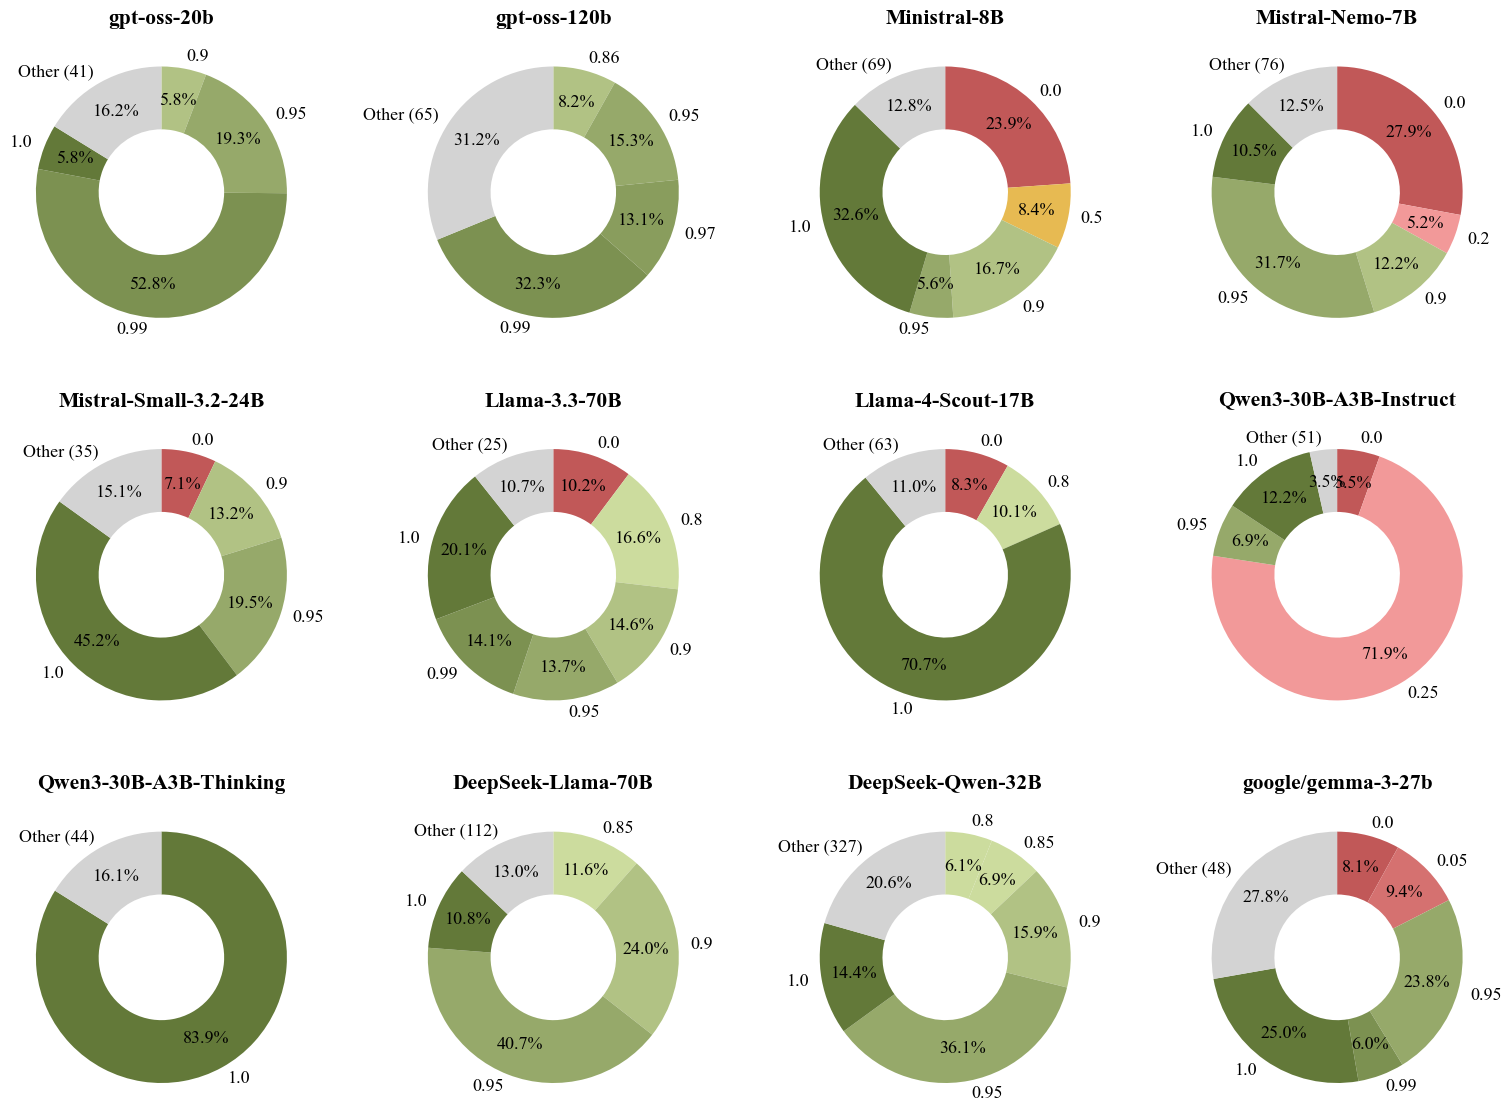

In [43]:
import matplotlib.pyplot as plt

scale_fonts(1.3)


import math
import matplotlib.pyplot as plt

def plot_donut_row_with_other(
        verbalized_metadata,
        threshold_pct=8,
        figsize_per_chart=(4, 4),
        color_dict=None,
        ncols=4  # 🔹 new argument: max number of columns per row
):
    """
    Draw a grid of donut charts (rows × columns).
    """
    color_dict = color_dict or {}

    # 1) Collect all big-labels across models
    all_labels = set()
    for vc in verbalized_metadata.values():
        total = vc.sum()
        print("total=",total)
        mask = (vc / total * 100) >= threshold_pct
        all_labels |= set(vc.index[mask])
    all_labels = sorted(all_labels)

    # 2) Build a color map
    cmap = plt.get_cmap('tab10')
    other_labels = [lbl for lbl in all_labels if lbl not in color_dict]
    color_map = {lbl: cmap(i % 10) for i, lbl in enumerate(other_labels)}
    color_map.update(color_dict)
    other_color = 'lightgrey'

    model_ids = list(verbalized_metadata.keys())
    n = len(models)
    nrows = math.ceil(n / ncols)  # 🔹 number of rows

    # figure size scales with rows and columns
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(figsize_per_chart[0] * ncols,
                 figsize_per_chart[1] * nrows)
    )

    # Flatten axes for easy iteration
    axes = axes.ravel() if n > 1 else [axes]

    for ax, model_id in zip(axes, model_ids):
        model = next(m for m in models if model_id in m["id"])
        vc = verbalized_metadata[model_id]
        total = vc.sum()
        mask = (vc / total * 100) >= threshold_pct
        big_labels = list(vc.index[mask])
        big_sizes = vc.loc[big_labels].values
        other_size = total - big_sizes.sum()

        labels_native = big_labels + ['Other']
        sizes = list(big_sizes) + [other_size]
        colors = [color_map[lbl] for lbl in big_labels] + [other_color]
        labels_for_plot = [str(lbl) for lbl in big_labels] + [f'Other ({len(vc) - len(big_labels)})']

        ax.pie(
            sizes,
            labels=labels_for_plot,
            colors=colors,
            autopct='%1.1f%%',
            pctdistance=0.74,
            startangle=90,
            counterclock=False,
            wedgeprops=dict(width=0.5)
        )
        ax.set_title(model["shortname"], pad=22, fontweight='bold')
        ax.axis('equal')

    # 🔹 Hide any unused subplots
    for ax in axes[n:]:
        ax.axis('off')

    plt.tight_layout(pad=3.0)
    return fig


# Example usage:
color_overrides = {
    0.0: "#C15858",
    0.05: "#D57170",
    0.2: "#F29999",
    0.25: "#F29999",
    0.5: "#E7BA52",
    0.8: "#ccdc9e",
    0.85: "#ccdc9e",
    0.86: "#b1c284",
    0.9: "#b1c284",
    0.95: "#96a96a",
    0.97: "#899D5D",
    0.99: "#7c9151",
    1.0: "#637939"
}  # red for 0.0, green for 1.0
for key in list(color_overrides.keys()):
    color_overrides[str(key)] = color_overrides[key]  # when loaded from file, keys are strings
fig = plot_donut_row_with_other(
    verbalized_metadata,
    threshold_pct=5,
    color_dict=color_overrides
)
for ext in ["svg", "pdf", "png"]:
    plt.savefig(f"resources/figures/verbalized_value_distribution_full.{ext}", bbox_inches="tight")
plt.show()
mpl.rcdefaults()
# plt.rcParams['font.family'] = 'Palatino Linotype'
plt.rcParams['font.family'] = 'Times New Roman'

# P(True)

In [44]:
bucket_counts_total_per_model = dict()
for model in models:
    bucket_counts_total = np.array([0] * 15)
    for dataset_id, dataset in datasets_combined.items():
        print(f"Processing {dataset_id}/{model['id']} ...")
        bucket_counts = np.array(cached_data[model['id']][dataset_id]["p_true"]["bucket_counts"])
        bucket_counts_total += bucket_counts
    bucket_counts_total_per_model[model['id']] = bucket_counts_total

Processing MMLU/gpt-oss-20b ...
Processing ARC_Easy/gpt-oss-20b ...
Processing ARC_Challenge/gpt-oss-20b ...
Processing SciQ/gpt-oss-20b ...
Processing GPQA/gpt-oss-20b ...
Processing GSM8K/gpt-oss-20b ...
Processing SVamp/gpt-oss-20b ...
Processing SciBench/gpt-oss-20b ...
Processing MMLU/gpt-oss-120b ...
Processing ARC_Easy/gpt-oss-120b ...
Processing ARC_Challenge/gpt-oss-120b ...
Processing SciQ/gpt-oss-120b ...
Processing GPQA/gpt-oss-120b ...
Processing GSM8K/gpt-oss-120b ...
Processing SVamp/gpt-oss-120b ...
Processing SciBench/gpt-oss-120b ...
Processing MMLU/Ministral-8B-Instruct-2410 ...
Processing ARC_Easy/Ministral-8B-Instruct-2410 ...
Processing ARC_Challenge/Ministral-8B-Instruct-2410 ...
Processing SciQ/Ministral-8B-Instruct-2410 ...
Processing GPQA/Ministral-8B-Instruct-2410 ...
Processing GSM8K/Ministral-8B-Instruct-2410 ...
Processing SVamp/Ministral-8B-Instruct-2410 ...
Processing SciBench/Ministral-8B-Instruct-2410 ...
Processing MMLU/Mistral-Nemo-Instruct-2407 ...


['gpt-oss-20b', 'gpt-oss-120b', 'Ministral-8B-Instruct-2410', 'Mistral-Nemo-Instruct-2407', 'Mistral-Small-3.2-24B-Instruct-2506', 'Llama-3.3-70B-Instruct', 'Llama-4-Scout-17B-16E-Instruct', 'Qwen3-30B-A3B-Instruct-2507', 'Qwen3-30B-A3B-Thinking-2507', 'DeepSeek-R1-Distill-Llama-70B', 'DeepSeek-R1-Distill-Qwen-32B', 'gemma-3-27b-it']


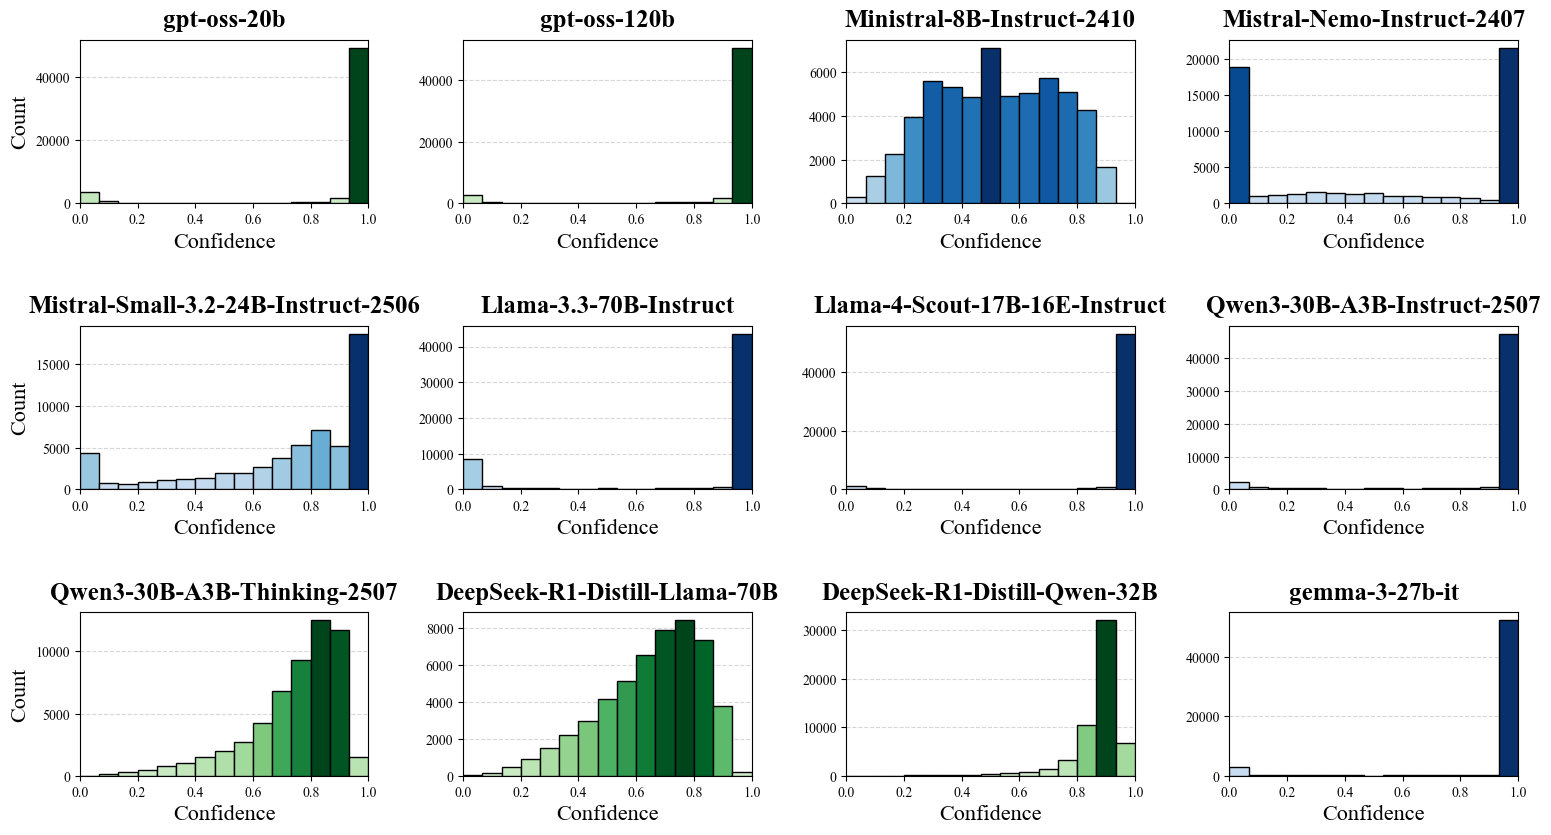

In [45]:
import numpy as np
import matplotlib.pyplot as plt



def plot_bucket_distribution(
    bucket_counts_total_per_model,
    figsize_per_chart=(4, 3),
    ncols=4  # 🔹 new: max number of columns per row
):
    """
    Plots a grid of bar charts for each model showing the distribution of bucket counts.

    Parameters
    ----------
    bucket_counts_total_per_model : dict[str, np.ndarray]
        Mapping model names → arrays of bucket counts.
    figsize_per_chart : tuple[int, int]
        Size of each subplot (width, height) in inches.
    ncols : int
        Maximum number of columns in the subplot grid.
    """
    model_ids = list(bucket_counts_total_per_model.keys())
    print(model_ids)
    n_models = len(model_ids)
    n_bins = len(next(iter(bucket_counts_total_per_model.values())))
    bin_centers = np.linspace(0, 1, n_bins, endpoint=False) + 0.5 / n_bins

    nrows = math.ceil(n_models / ncols)  # 🔹 compute rows automatically
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_chart[0] * ncols, figsize_per_chart[1] * nrows)
    )

    # Flatten axes for easy iteration
    axes = axes.ravel() if n_models > 1 else [axes]

    for idx, (ax, model_id) in enumerate(zip(axes, model_ids)):
        model_type = next(m for m in models if model_id in m["name"])["type"]
        cmap = plt.colormaps["Blues" if model_type == "instruct" else "Greens"]
        counts = bucket_counts_total_per_model[model_id]
        norm_counts = counts / counts.max()
        colors = [cmap(c * 0.8 + 0.2) for c in norm_counts]

        ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)
        ax.bar(
            bin_centers,
            counts,
            width=1.0 / n_bins,
            color=colors,
            edgecolor="black",
            zorder=3
        )
        ax.set_title(model_id, fontsize=18, fontweight="bold", y=1.03)
        ax.set_xlim(0, 1)
        ax.set_xlabel("Confidence", fontsize=16)
        if idx % ncols == 0:  # only leftmost plots get y-label
            ax.set_ylabel("Count", fontsize=16)

    # 🔹 Hide any unused subplot slots
    for ax in axes[n_models:]:
        ax.axis("off")

    plt.tight_layout(pad=3.0)
    return fig


# Example usage:
fig = plot_bucket_distribution(bucket_counts_total_per_model)
for ext in ["svg", "pdf", "png"]:
    plt.savefig(f"resources/figures/ptrue_bucket_counts_full.{ext}", bbox_inches="tight")
plt.show()